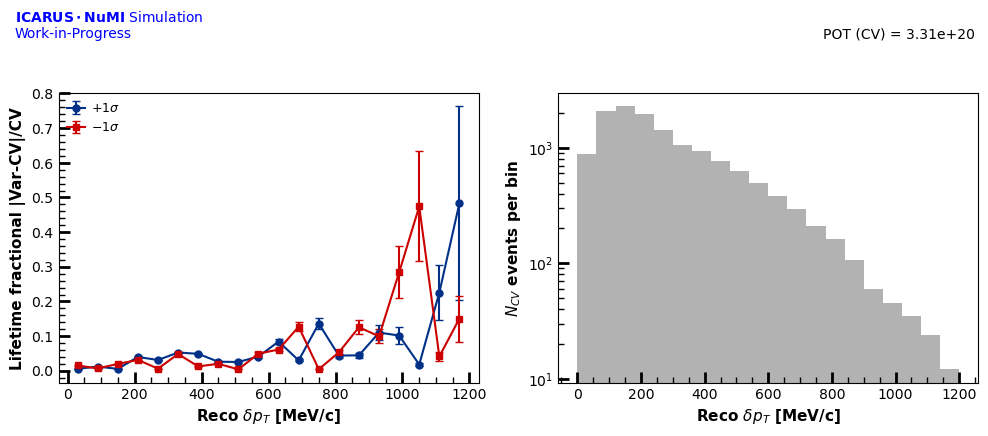

Saved: lifetime_dpT_stats_contained


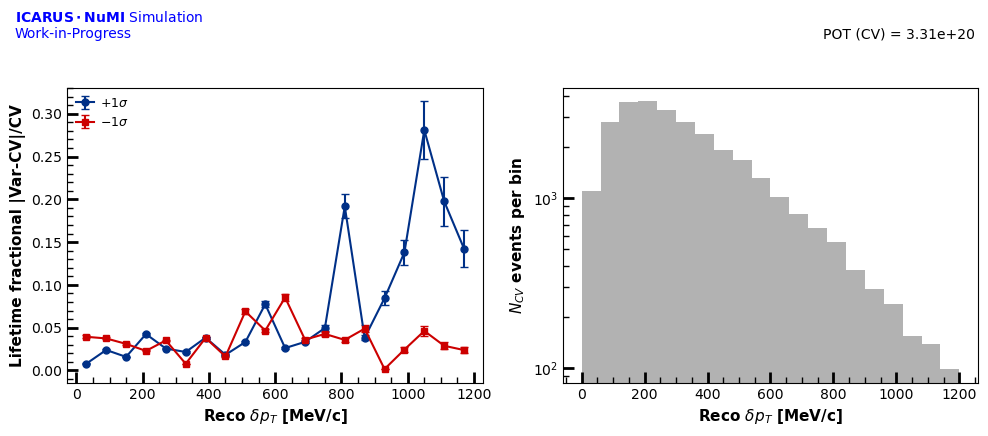

Saved: lifetime_dpT_stats_exiting


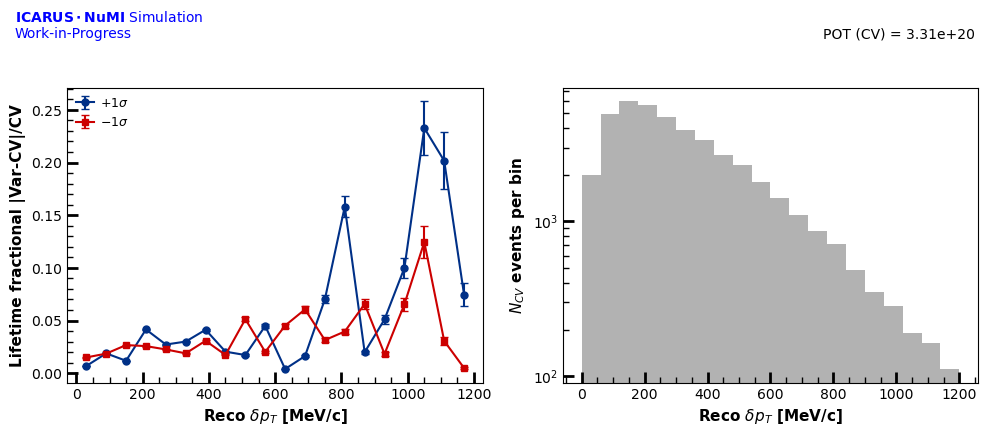

Saved: lifetime_dpT_stats_combined


In [1]:
# Lifetime fractional uncertainty vs. delta_pT -- supporting figure for
# reviewer comments #18 (Anne, Fig 32) and 4.3 (London).
#
# Shows, for the contained/exiting/combined samples, the Lifetime (var04)
# fractional |Var-CV|/CV difference binned by reco_dpT_lp (left panel) next
# to the raw CV event count per bin on a log scale (right panel). The point
# is to demonstrate that the apparent rise in fractional uncertainty at high
# delta_pT tracks the collapse in bin statistics there, rather than being a
# genuine growing physical effect -- i.e. it's a statistics artifact, the
# same mechanism found for the Cathode Bending proximity check (#17).
#
# Binning matches variables_uncontained.toml's reco_dpT definition exactly:
# key = reco_dpT_lp, range [0,1200] MeV/c, 20 bins of 60 MeV/c each.
#
# CV/var04p/var04m are independent MC productions, POT-normalized the same
# way as the Cathode Bending check (NORM = POT_cv / POT_variation).

import os
import uproot
import numpy as np
import matplotlib.pyplot as plt

OUT_DIR = os.getcwd()

MEDULLA_INPUT = (
    "/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/"
    "My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/"
    "ICARUS_CC0pi_Selection/data/1muNp0pi_Nge1_uncontained.root"
)

DPT_BRANCH = "reco_dpT_lp"
CONTAINMENT = "reco_leading_muon_containment"

f = uproot.open(MEDULLA_INPUT)
cv_tree = f["events/cv/selected"]
p_tree = f["events/var04p/selected"]
m_tree = f["events/var04m/selected"]

pot_cv = f["events/cv/POT"].to_numpy()[0].sum()
pot_p = f["events/var04p/POT"].to_numpy()[0].sum()
pot_m = f["events/var04m/POT"].to_numpy()[0].sum()
NORM_P, NORM_M = pot_cv / pot_p, pot_cv / pot_m

cv_arrs = cv_tree.arrays([DPT_BRANCH, CONTAINMENT], library="np")
p_arrs = p_tree.arrays([DPT_BRANCH, CONTAINMENT], library="np")
m_arrs = m_tree.arrays([DPT_BRANCH, CONTAINMENT], library="np")

DPT_BINS = np.linspace(0, 1200, 21)  # 20 bins of 60 MeV/c, matches reco_dpT definition
CENTERS = 0.5 * (DPT_BINS[:-1] + DPT_BINS[1:])

def frac_diff(var_y, norm, cv_y):
    scaled = var_y * norm
    diff = np.divide(np.abs(scaled - cv_y), cv_y,
                      out=np.full_like(cv_y, np.nan, dtype=float), where=cv_y > 0)
    rel_err = np.sqrt(
        np.divide(1.0, var_y, out=np.full_like(var_y, np.nan, dtype=float), where=var_y > 0)
        + np.divide(1.0, cv_y, out=np.full_like(cv_y, np.nan, dtype=float), where=cv_y > 0)
    )
    return diff, diff * rel_err

# None = no containment mask -> all events (the combined sample)
CATEGORIES = [
    ("contained", True),
    ("exiting", False),
    ("combined", None),
]

for sub in ("pdf", "jpeg"):
    os.makedirs(os.path.join(OUT_DIR, sub), exist_ok=True)

for name, is_contained in CATEGORIES:
    if is_contained is None:
        cv_mask = np.ones(len(cv_arrs[CONTAINMENT]), dtype=bool)
        p_mask = np.ones(len(p_arrs[CONTAINMENT]), dtype=bool)
        m_mask = np.ones(len(m_arrs[CONTAINMENT]), dtype=bool)
    else:
        cv_mask = cv_arrs[CONTAINMENT].astype(bool) == is_contained
        p_mask = p_arrs[CONTAINMENT].astype(bool) == is_contained
        m_mask = m_arrs[CONTAINMENT].astype(bool) == is_contained

    cv_y, _ = np.histogram(cv_arrs[DPT_BRANCH][cv_mask], bins=DPT_BINS)
    p_y, _ = np.histogram(p_arrs[DPT_BRANCH][p_mask], bins=DPT_BINS)
    m_y, _ = np.histogram(m_arrs[DPT_BRANCH][m_mask], bins=DPT_BINS)

    frac_p, err_p = frac_diff(p_y, NORM_P, cv_y)
    frac_m, err_m = frac_diff(m_y, NORM_M, cv_y)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    ax = axes[0]
    ax.errorbar(CENTERS, frac_p, yerr=err_p, marker="o", color="#003087",
                linestyle="-", linewidth=1.5, markersize=5, capsize=3,
                label=r"$+1\sigma$")
    ax.errorbar(CENTERS, frac_m, yerr=err_m, marker="s", color="#CC0000",
                linestyle="-", linewidth=1.5, markersize=5, capsize=3,
                label=r"$-1\sigma$")
    ax.set_xlabel("Reco $\\delta p_T$ [MeV/c]", fontsize=11, fontweight="bold",
                  fontfamily="sans-serif")
    ax.set_ylabel("Lifetime fractional |Var-CV|/CV", fontsize=11, fontweight="bold",
                  fontfamily="sans-serif")
    ax.tick_params(axis="both", which="major", labelsize=10, size=8, width=2, direction="in")
    ax.minorticks_on()
    ax.tick_params(axis="both", which="minor", size=4, width=1, direction="in")
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontfamily("sans-serif")
    ax.legend(fontsize=9, loc="upper left", framealpha=0.0, edgecolor="none",
              handlelength=1.4, handletextpad=0.5, borderaxespad=0.3)

    ax2 = axes[1]
    ax2.bar(CENTERS, cv_y, width=np.diff(DPT_BINS), color="gray", alpha=0.6)
    ax2.set_yscale("log")
    ax2.set_xlabel("Reco $\\delta p_T$ [MeV/c]", fontsize=11, fontweight="bold",
                   fontfamily="sans-serif")
    ax2.set_ylabel("$N_{CV}$ events per bin", fontsize=11, fontweight="bold",
                   fontfamily="sans-serif")
    ax2.tick_params(axis="both", which="major", labelsize=10, size=8, width=2, direction="in")
    ax2.minorticks_on()
    ax2.tick_params(axis="both", which="minor", size=4, width=1, direction="in")
    for lbl in ax2.get_xticklabels() + ax2.get_yticklabels():
        lbl.set_fontfamily("sans-serif")

    fig.text(0.02, 1.0, r"$\bf{ICARUS \cdot NuMI}$ Simulation" + "\n" + "Work-in-Progress",
              fontsize=10, color="blue", verticalalignment="bottom", fontfamily="sans-serif")
    fig.text(0.98, 1.0, f"POT (CV) = {pot_cv:.2e}",
              fontsize=10, color="black", verticalalignment="bottom",
              horizontalalignment="right", fontfamily="sans-serif")

    fig.tight_layout(rect=[0, 0, 1, 0.92])
    fig.savefig(os.path.join(OUT_DIR, f"pdf/lifetime_dpT_stats_{name}.pdf"),
                bbox_inches="tight", dpi=300)
    fig.savefig(os.path.join(OUT_DIR, f"jpeg/lifetime_dpT_stats_{name}.jpeg"),
                bbox_inches="tight", dpi=300)
    plt.show()
    print(f"Saved: lifetime_dpT_stats_{name}")
